In [22]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

In [43]:
df = pd.read_csv('../../static\data\dataset_2.csv')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\alika\AppData\Local\Temp\ipykernel_30484\2472533709.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('../../static\data\dataset_2.csv')


In [44]:
df.head()

,spkid,full_name,neo,pha,diameter,diameter_sigma,e,a,i,om,...,sigma_e,sigma_a,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_n,H,H_sigma,moid
0,20000001,1 Ceres (A801 AA),N,N,939.400,0.20,0.0796,2.766,10.59,80.25,...,4.800000e-12,1.000000e-11,4.600000e-09,6.200000e-08,6.600000e-08,6.200000e-09,1.200000e-12,3.34,NaN,1.58
1,20000002,2 Pallas (A802 FA),N,N,513.000,6.00,0.2306,2.770,34.93,172.89,...,5.800000e-09,1.800000e-09,6.900000e-07,1.300000e-06,2.400000e-06,2.500000e-06,2.000000e-10,4.11,NaN,1.23
2,20000003,3 Juno (A804 RA),N,N,246.596,10.59,0.2558,2.671,12.99,169.82,...,4.400000e-09,1.500000e-09,3.700000e-07,2.100000e-06,2.200000e-06,8.000000e-07,1.900000e-10,5.19,NaN,1.04
3,20000004,4 Vesta (A807 FA),N,N,522.770,0.10,0.0902,2.362,7.14,103.70,...,2.300000e-10,1.500000e-09,2.200000e-07,3.900000e-07,1.900000e-07,1.800000e-06,2.600000e-10,3.25,NaN,1.13
4,20000005,5 Astraea (A845 XA),N,N,106.699,3.14,0.1875,2.577,5.36,141.45,...,2.000000e-09,1.300000e-09,1.900000e-07,2.100000e-06,2.200000e-06,8.600000e-07,1.900000e-10,6.99,NaN,1.11


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1471961 entries, 0 to 1471960
Data columns (total 23 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   spkid           1471961 non-null  int64  
 1   full_name       1471961 non-null  object 
 2   neo             1468128 non-null  object 
 3   pha             1465225 non-null  object 
 4   diameter        139696 non-null   float64
 5   diameter_sigma  139480 non-null   float64
 6   e               1471961 non-null  float64
 7   a               1470199 non-null  float64
 8   i               1471961 non-null  float64
 9   om              1471961 non-null  float64
 10  w               1471961 non-null  float64
 11  ma              1470198 non-null  float64
 12  n               1470199 non-null  float64
 13  sigma_e         1467423 non-null  float64
 14  sigma_a         1467384 non-null  float64
 15  sigma_i         1467423 non-null  float64
 16  sigma_om        1467423 non-null  fl

In [46]:
df['neo'].value_counts()

neo
N    1428371
Y      39757
Name: count, dtype: int64

In [47]:
df['pha'].value_counts()

pha
N    1462711
Y       2514
Name: count, dtype: int64

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100building tree 19 of 100

building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    6.8s


building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   29.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


Confusion Matrix for NEO prediction:
[[285168     39]
 [    82   7755]]


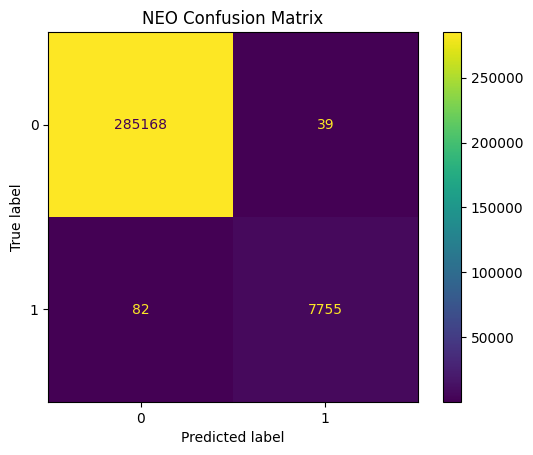

KeyboardInterrupt: 

In [48]:
# Drop 'full_name' and 'spkid' columns, and rows with missing target values
df_model = df.drop(['full_name', 'spkid'], axis=1).dropna(subset=['neo', 'pha'])

# Prepare features and targets
X = df_model.drop(['neo', 'pha'], axis=1)
y_neo = df_model['neo']
y_pha = df_model['pha']

# Fill missing values in features
X = X.fillna(X.median())

# Encode targets
y_neo = y_neo.map({'Y': 1, 'N': 0})
y_pha = y_pha.map({'Y': 1, 'N': 0})

# Single train/test split used for both tasks (keeps evaluation consistent)
X_train, X_test, y_train_neo, y_test_neo, y_train_pha, y_test_pha = train_test_split(
    X, y_neo, y_pha, test_size=0.2, random_state=42
)

# ---- NEO model ----
neo_clf = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1, verbose=2)
neo_clf.fit(X_train, y_train_neo)
y_pred_neo = neo_clf.predict(X_test)
cm_neo = confusion_matrix(y_test_neo, y_pred_neo)
print("Confusion Matrix for NEO prediction:")
print(cm_neo)
ConfusionMatrixDisplay(confusion_matrix=cm_neo, display_labels=neo_clf.classes_).plot()
plt.title("NEO Confusion Matrix")
plt.show()

# ---- Prepare NEO-derived feature for PHA model without leaking test labels ----
# Generate out-of-fold predictions on the training set (oof preds)
neo_oof = cross_val_predict(
    RandomForestClassifier(random_state=42),
    X_train,
    y_train_neo,
    cv=5,
    method='predict'
)

# Train a final NEO model on the whole training set to predict test-set NEO labels
neo_final = RandomForestClassifier(random_state=42, n_estimators=300, class_weight="balanced", n_jobs=-1, verbose=2)
neo_final.fit(X_train, y_train_neo)
neo_test_pred = neo_final.predict(X_test)

# Create PHA feature sets that include the NEO prediction
X_train_pha = X_train.copy()
X_train_pha['neo_pred'] = neo_oof
X_test_pha = X_test.copy()
X_test_pha['neo_pred'] = neo_test_pred

# ---- PHA model (uses NEO prediction as a feature) ----
pha_clf = RandomForestClassifier(random_state=42)
pha_clf.fit(X_train_pha, y_train_pha)
y_pred_pha = pha_clf.predict(X_test_pha)
cm_pha = confusion_matrix(y_test_pha, y_pred_pha)
print("Confusion Matrix for PHA prediction (includes NEO prediction as a feature):")
print(cm_pha)
ConfusionMatrixDisplay(confusion_matrix=cm_pha, display_labels=pha_clf.classes_).plot()
plt.title("PHA Confusion Matrix (with NEO feature)")
plt.show()

In [49]:
imp = pd.Series(neo_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top NEO features:\n", imp.head(10))
imp2 = pd.Series(pha_clf.feature_importances_, index=X_train_pha.columns).sort_values(ascending=False)
print("Top PHA features:\n", imp2.head(10))

Top NEO features:
 moid        0.430218
H           0.173390
n           0.127798
e           0.108436
a           0.090856
sigma_n     0.014191
sigma_w     0.013487
sigma_ma    0.007473
sigma_e     0.006406
sigma_a     0.006311
dtype: float64
Top PHA features:
 e           0.128953
sigma_e     0.078104
i           0.073237
sigma_i     0.068035
n           0.066827
a           0.066073
sigma_w     0.064564
sigma_ma    0.064458
sigma_a     0.064322
sigma_n     0.060025
dtype: float64


In [50]:
X_train_pha.head()

,diameter,diameter_sigma,e,a,i,om,w,ma,n,sigma_e,sigma_a,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_n,neo_pred
640380,3.95,0.34,0.2228,3.947,3.96,125.64,268.06,88.87,0.12570,6.500000e-08,4.500000e-08,5.600000e-06,1.100000e-04,1.100000e-04,0.000019,2.100000e-09,0
309787,3.95,0.34,0.1418,2.367,1.49,310.33,247.18,165.11,0.27060,4.700000e-08,7.200000e-09,3.800000e-06,1.700000e-04,1.700000e-04,0.000013,1.200000e-09,0
1295902,3.95,0.34,0.0936,5.220,8.53,90.14,342.37,71.84,0.08265,2.200000e-07,1.000000e-06,1.500000e-05,1.800000e-04,2.800000e-04,0.000210,2.400000e-08,0
100426,3.95,0.34,0.2092,2.756,11.54,211.88,88.42,108.65,0.21550,3.300000e-09,3.000000e-09,1.800000e-07,5.500000e-07,9.300000e-07,0.000001,3.500000e-10,0
1386605,3.95,0.34,0.0916,2.671,2.39,299.15,43.00,279.80,0.22580,1.400000e-05,2.100000e-06,3.200000e-05,6.900000e-04,2.300000e-03,0.002700,2.700000e-07,0


In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

# Print model parameter summary before training
def print_model_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model: {model.__class__.__name__}")
    print(f"Total params: {total:,}")
    print(f"Trainable params: {trainable:,}\n")
    # print("Per-parameter details:")
    # for name, p in model.named_parameters():
    #     print(f"  {name:40s} shape={tuple(p.shape):20s} trainable={p.requires_grad} params={p.numel():,}")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Prepare numpy arrays
X_train_np = X_train.values.astype('float32')
X_test_np = X_test.values.astype('float32')
y_train_np = pd.concat([y_train_neo, y_train_pha], axis=1).values.astype('float32')  # shape (n,2)
y_test_np = pd.concat([y_test_neo, y_test_pha], axis=1).values.astype('float32')

# Scale features
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_test_np = scaler.transform(X_test_np)

# Datasets / loaders
batch_size = 128
train_ds = TensorDataset(torch.from_numpy(X_train_np), torch.from_numpy(y_train_np))
test_ds = TensorDataset(torch.from_numpy(X_test_np), torch.from_numpy(y_test_np))
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

# Very deep FC network with small hidden sizes
class DeepSmallFC(nn.Module):
    def __init__(self, in_dim, hidden=32, depth=12, out_dim=2, act=nn.GELU):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_dim, hidden))
        layers.append(act())
        for _ in range(depth - 1):
            layers.append(nn.Linear(hidden, hidden))
            layers.append(act())
        layers.append(nn.Linear(hidden, out_dim))  # logits for two binary tasks
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = DeepSmallFC(in_dim=X_train_np.shape[1], hidden=128, depth=6, out_dim=2).to(device)
print_model_params(model)

# Compute pos_weight per task from training labels and boost PHA importance
# y_train_np shape is (n,2) with columns [neo, pha]
eps = 1e-6
pos_counts = y_train_np.sum(axis=0)                # positives per task
neg_counts = y_train_np.shape[0] - pos_counts
pos_weight = (neg_counts + eps) / (pos_counts + eps)  # neg/pos ratio

# optionally amplify PHA importance (user-controlled)
pha_boost = 2.0   # increase PHA loss importance (tune this)
pos_weight[1] = pos_weight[1] * pha_boost
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(device)
print(f"pos_weight (neo, pha): {pos_weight} -> tensor {pos_weight_tensor}")

# Loss using pos_weight (applies per-output when targets shape (N,2))
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Training loop (unchanged besides loss)
n_epochs = 50
model.train()
for epoch in range(1, n_epochs + 1):
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}", leave=False)
    for xb, yb in pbar:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)               # shape (B,2)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
        pbar.set_postfix(loss=loss.item())
    epoch_loss /= len(train_ds)
    print(f"Epoch {epoch}/{n_epochs} avg loss: {epoch_loss:.4f}")


# Evaluation
model.eval()
all_logits = []
all_targets = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        all_logits.append(logits.cpu())
        all_targets.append(yb)
all_logits = torch.cat(all_logits, dim=0).numpy()
all_targets = torch.cat(all_targets, dim=0).numpy()

probs = torch.sigmoid(torch.from_numpy(all_logits)).numpy()
preds = (probs >= 0.5).astype(int)

# Separate results
pred_neo = preds[:, 0]
pred_pha = preds[:, 1]
true_neo = all_targets[:, 0].astype(int)
true_pha = all_targets[:, 1].astype(int)

print("NEO classification report:")
print(classification_report(true_neo, pred_neo, zero_division=0))
print("NEO confusion matrix:")
print(confusion_matrix(true_neo, pred_neo))

print("PHA classification report:")
print(classification_report(true_pha, pred_pha, zero_division=0))
print("PHA confusion matrix:")
print(confusion_matrix(true_pha, pred_pha))

Using device: cuda
Model: DeepSmallFC
Total params: 85,378
Trainable params: 85,378

pos_weight (neo, pha): [  36.11411202 1143.82111437] -> tensor tensor([  36.1141, 1143.8212], device='cuda:0')


Epoch 1/50 avg loss: 0.0845


Epoch 2/50 avg loss: 0.0275


Epoch 3/50 avg loss: 0.0259


Epoch 4/50 avg loss: 0.0222


Epoch 5/50 avg loss: 0.0225


KeyboardInterrupt: 

In [69]:
# Evaluation
model.eval()
all_logits = []
all_targets = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        all_logits.append(logits.cpu())
        all_targets.append(yb)
all_logits = torch.cat(all_logits, dim=0).numpy()
all_targets = torch.cat(all_targets, dim=0).numpy()

probs = torch.sigmoid(torch.from_numpy(all_logits)).numpy()
preds = (probs >= 0.5).astype(int)

# Separate results
pred_neo = preds[:, 0]
pred_pha = preds[:, 1]
true_neo = all_targets[:, 0].astype(int)
true_pha = all_targets[:, 1].astype(int)

print("NEO classification report:")
print(classification_report(true_neo, pred_neo, zero_division=0))
print("NEO confusion matrix:")
print(confusion_matrix(true_neo, pred_neo))

print("PHA classification report:")
print(classification_report(true_pha, pred_pha, zero_division=0))
print("PHA confusion matrix:")
print(confusion_matrix(true_pha, pred_pha))

NEO classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    285207
           1       0.98      1.00      0.99      7837

    accuracy                           1.00    293044
   macro avg       0.99      1.00      0.99    293044
weighted avg       1.00      1.00      1.00    293044

NEO confusion matrix:
[[285033    174]
 [     6   7831]]
PHA classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    292576
           1       0.19      1.00      0.32       468

    accuracy                           0.99    293044
   macro avg       0.59      1.00      0.66    293044
weighted avg       1.00      0.99      1.00    293044

PHA confusion matrix:
[[290578   1998]
 [     0    468]]


PHA AUC: 0.9981
Youden threshold: 0.9067  (FPR=0.0059, TPR=1.0000)
F1-opt threshold: 0.9966


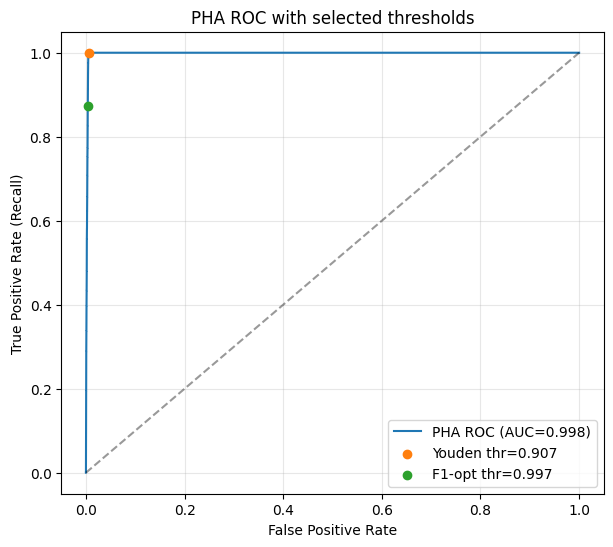

In [66]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
import numpy as np

# ensure probs and true_pha exist (from your evaluation block)
probs_pha = probs[:, 1]
y_true = true_pha

# ROC and AUC
fpr, tpr, roc_thr = roc_curve(y_true, probs_pha)
auc_val = roc_auc_score(y_true, probs_pha)

# pick thresholds:
# 1) Youden's J (maximize tpr - fpr)
j_idx = np.nanargmax(tpr - fpr)
j_thr = roc_thr[j_idx]

# 2) best F1 from precision-recall curve
prec, rec, pr_thr = precision_recall_curve(y_true, probs_pha)
f1 = 2 * (prec * rec) / (prec + rec + 1e-12)
# precision_recall_curve returns thr length = len(prec)-1, align safely
if len(pr_thr):
    f1_idx = np.nanargmax(f1[:-1])
    f1_thr = pr_thr[f1_idx]
else:
    f1_thr = 0.5

print(f"PHA AUC: {auc_val:.4f}")
print(f"Youden threshold: {j_thr:.4f}  (FPR={fpr[j_idx]:.4f}, TPR={tpr[j_idx]:.4f})")
print(f"F1-opt threshold: {f1_thr:.4f}")

# Plot ROC and mark thresholds
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'PHA ROC (AUC={auc_val:.3f})')
plt.scatter(fpr[j_idx], tpr[j_idx], c='C1', label=f"Youden thr={j_thr:.3f}", zorder=5)
# mark F1-opt point by finding nearest ROC point to F1 threshold
f1_mask = probs_pha >= f1_thr
if f1_mask.any():
    # compute operating point for chosen f1_thr on test set
    tpr_f1 = tpr[np.argmin(np.abs(roc_thr - f1_thr))] if len(roc_thr) else None
    fpr_f1 = fpr[np.argmin(np.abs(roc_thr - f1_thr))] if len(roc_thr) else None
    if tpr_f1 is not None:
        plt.scatter(fpr_f1, tpr_f1, c='C2', label=f"F1-opt thr={f1_thr:.3f}", zorder=5)

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('PHA ROC with selected thresholds')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [71]:
import torch
import onnx

# ensure model and feature shape available (model, X_train_np)
model.eval()
model_cpu = model.to('cpu')

# dummy input matching feature dim
dummy_input = torch.randn(1, X_train_np.shape[1], dtype=torch.float32)

export_path = "astratek_model.onnx"
torch.onnx.export(
    model_cpu,
    dummy_input,
    export_path,
    export_params=True,
    opset_version=13,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['logits'],
    dynamic_axes={'input': {0: 'batch_size'}, 'logits': {0: 'batch_size'}},
)

# quick ONNX sanity check
onnx_model = onnx.load(export_path)
onnx.checker.check_model(onnx_model)
print(f"Exported ONNX model to {export_path}")

Exported ONNX model to astratek_model.onnx


C:\Users\alika\AppData\Local\Temp\ipykernel_30484\1062964926.py:12: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
